# Simulación Monte Carlo - Colisiones en RACH LTE/5G


## Introducción

La simulación Monte Carlo es una técnica que permite modelar sistemas probabilísticos mediante experimentos repetidos. Es relevante porque permite estudiar sistemas donde interviene el azar y cuyo análisis exacto resulta complejo.

En sistemas LTE/5G, el canal RACH (Random Access Channel) permite a múltiples usuarios solicitar acceso simultáneamente. Los dispositivos seleccionan preámbulos de forma aleatoria, lo que dificulta un análisis determinista. Mediante simulación, es posible estimar la probabilidad de colisiones, evaluar el rendimiento del sistema bajo diferentes condiciones y analizar el impacto de variables como el número de usuarios o de preámbulos. Además, su flexibilidad permite adaptarse fácilmente a escenarios más complejos, siendo una herramienta fundamental en el diseño y optimización de redes de comunicación.

En el escenario que estamos evaluando, vemos que cuando varios dispositivos eligen el mismo preámbulo, ocurre una colisión, lo cual reduce la eficiencia del sistema y estudiamos el comportamiento conforme varían los parámetros utilizados para evaluar el gráfico, en conjunto con esto estudiamos la probabilidad de colisión mediante la simulación de un escenario que nos permite identificar la frecuencia con la cual ocurre dicha colisión.



## Marco Teórico

La probabilidad de que NO haya colisión es:

P(no colisión) = (P/P) * ((P-1)/P) * ((P-2)/P) * ... * ((P-N+1)/P)

Entonces la probabilidad de al menos una colisión es:

P(colisión) = 1 - P(no colisión)

Donde:
- P = número de preámbulos
- N = número de usuarios

Debido a la complejidad, se utiliza la técnica de simulación Monte Carlo.



## Datos del problema

- Número de preámbulos (P): 64
- Número de UEs (N): 30
- Selección aleatoria uniforme
- Modo de Simulación: Monte Carlo


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

def prob_colision(N, P=64, simulaciones=10000):
    colisiones = 0
    for _ in range(simulaciones):
        elecciones = np.random.randint(0, P, size=N)
        if len(np.unique(elecciones)) < N:
            colisiones += 1
    return colisiones / simulaciones


In [9]:

N=30
P=64
print('Probabilidad colisión:', prob_colision(N,P))


Probabilidad colisión: 0.9996


In [20]:

valores_N = range(1,80)
probs = [prob_colision(n,64) for n in valores_N]

N_50 = valores_N[np.argmin(np.abs(np.array(probs)-0.5))]
print('N para 50%:', N_50)


N para 50%: 10


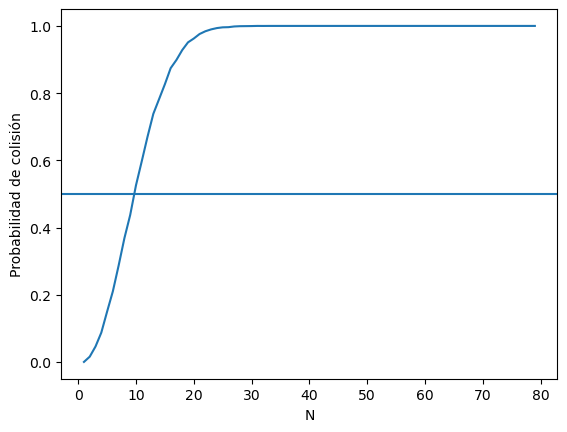

In [5]:

plt.plot(valores_N, probs)
plt.axhline(0.5)
plt.xlabel('N')
plt.ylabel('Probabilidad de colisión')
plt.show()


Si aumentamos los preámbulos, tendríamos la siguiente gráfica:

Probabilidad colisión: 0.2485


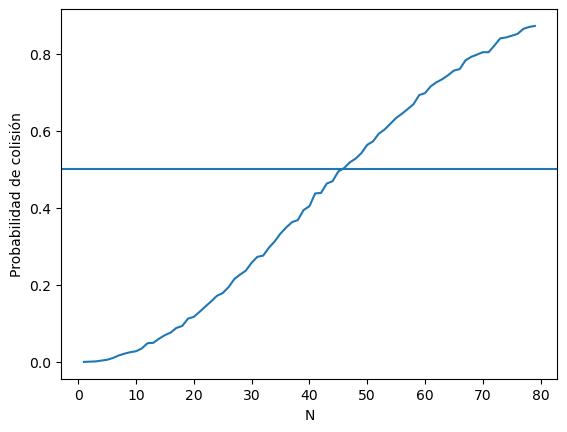

In [22]:
#Cambio de Valor de preambulos de 64 a 15000
P2=1500

#Recalculo de la probabilidad de Colision
def prob_colision2(N, P=1500, simulaciones=10000):
    colisiones = 0
    for _ in range(simulaciones):
        elecciones = np.random.randint(0, P, size=N)
        if len(np.unique(elecciones)) < N:
            colisiones += 1
    return colisiones / simulaciones

#Muestra del resultado del calculo de Colision
print('Probabilidad colisión:', prob_colision2(N,P2))

#Curva del grafico con el comportamiento conforme se agregan UE
valores_N = range(1,80)
probs = [prob_colision2(n,P2) for n in valores_N]


plt.plot(valores_N, probs)
plt.axhline(0.5)
plt.xlabel('N')
plt.ylabel('Probabilidad de colisión')
plt.show()


## Conclusiones de estas simulaciones

- La probabilidad de colisión crece rápidamente con N, esto hace que para todo N mayor de 30 con solamente 64 preámbulos disponibles, la probabilidad de colisión sea de un 100%.
- Aproximadamente 10 usuarios generan 50% de probabilidad de colisión.
- Con N=30, la colisión es casi segura y por esto luego de 30 el gráfico se mantiene fijo en 1.0, mostrando que conforme aumentan los UE, sin duda alguna estarán interfiriendo entre sí dentro de los 64 preámbulos disponibles.
- Al conservar la cantidad de UE inicial pero variar los preámbulos disponibles, identificamos que conforme vamos aumentando los preámbulos se reduce la cantidad de colisiones, dado que brinda mayor espacio de conexión para los UE y reduce la probabilidad de que escojan el mismo y colisionen en el RANCH.


Realizado por Kassey Tavárez ID 1015-2171